In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os


folder = "../data/processed"


files = [
    "Phoenix_environment.csv",
    "LA_environment.csv",
    "Seattle_environment.csv",
    "Houston_environment.csv",
    "NY_environment.csv",
    "Sacramento_environment.csv"
]


cities = {}

for file in files:
    city_name = file.replace("_environment.csv","")

    cities[city_name] = pd.read_csv(
        os.path.join(folder,file)
    )


cities.keys()

dict_keys(['Phoenix', 'LA', 'Seattle', 'Houston', 'NY', 'Sacramento'])

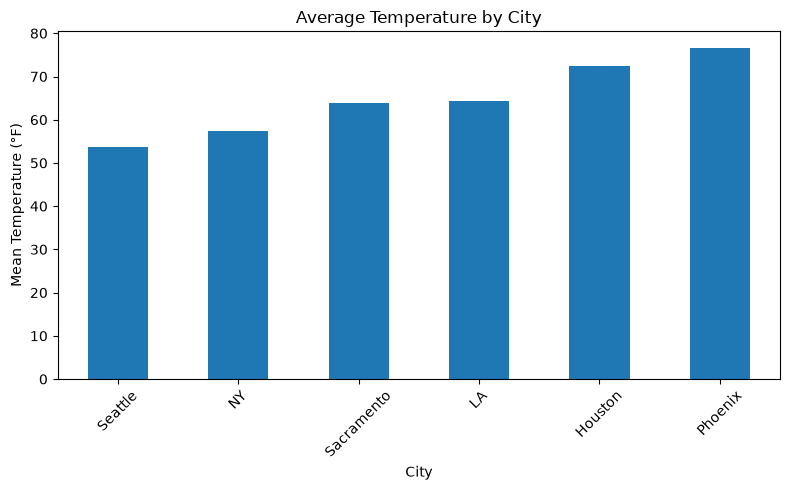

In [8]:
avg_temp = {}


for city, df in cities.items():

    avg_temp[city] = df["mean_temperature"].mean()


avg_temp = pd.Series(avg_temp).sort_values()


plt.figure(figsize=(8,5))

avg_temp.plot(
    kind="bar"
)


plt.title(
    "Average Temperature by City"
)

plt.xlabel("City")

plt.ylabel(
    "Mean Temperature (°F)"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

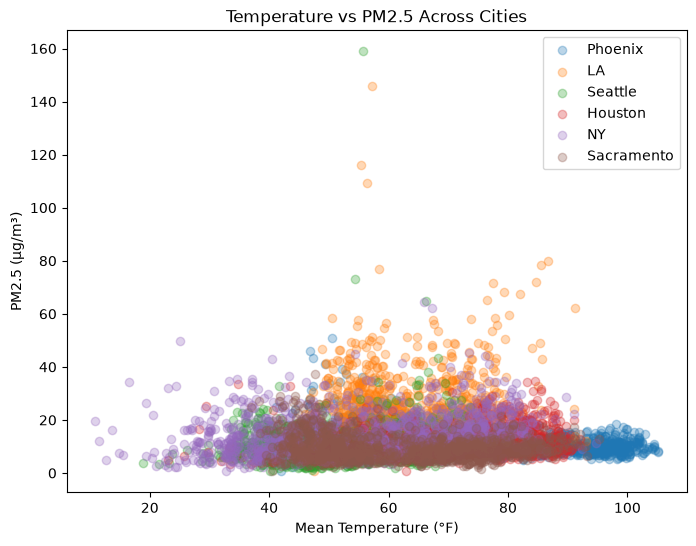

In [10]:
plt.figure(figsize=(8,6))


for city, df in cities.items():

    plt.scatter(
        df["mean_temperature"],
        df["pm25"],
        alpha=0.3,
        label=city
    )


plt.xlabel(
    "Mean Temperature (°F)"
)

plt.ylabel(
    "PM2.5 (µg/m³)"
)


plt.title(
    "Temperature vs PM2.5 Across Cities"
)


plt.legend()

plt.show()

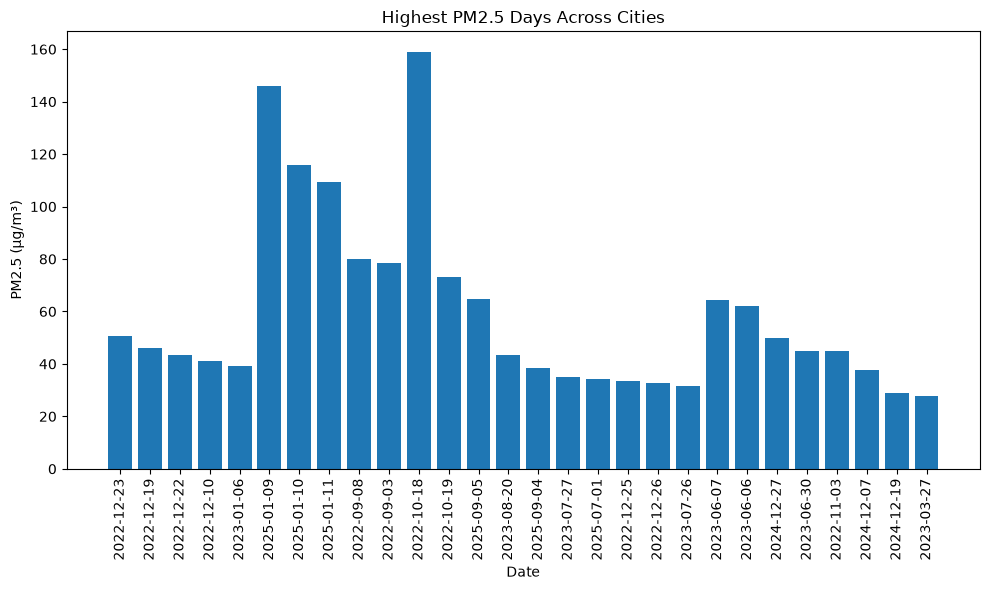

In [9]:
highest_days = []

for city, df in cities.items():

    temp = df.sort_values(
        "pm25",
        ascending=False
    ).head(5)

    temp["city"] = city

    highest_days.append(temp)


highest_days = pd.concat(
    highest_days
)


plt.figure(figsize=(10,6))


plt.bar(
    highest_days["date"].astype(str),
    highest_days["pm25"]
)


plt.title(
    "Highest PM2.5 Days Across Cities"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "PM2.5 (µg/m³)"
)


plt.xticks(
    rotation=90
)


plt.tight_layout()

plt.show()

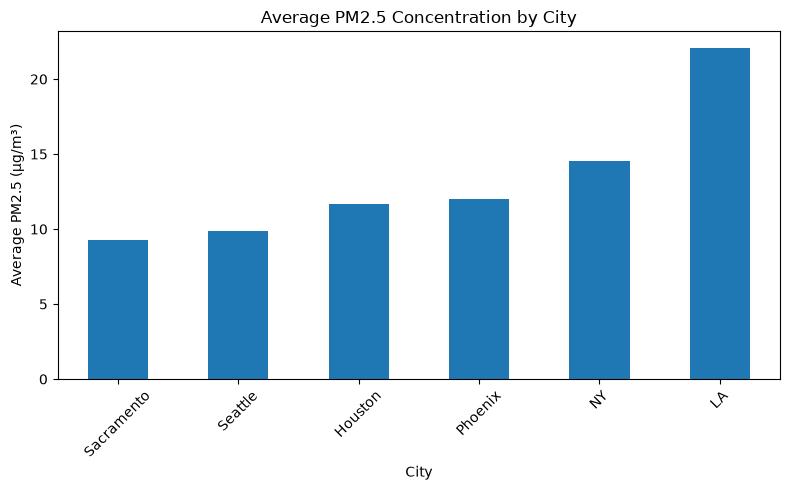

In [7]:
avg_pm25 = {}


for city, df in cities.items():

    avg_pm25[city] = df["pm25"].mean()


avg_pm25 = pd.Series(avg_pm25).sort_values()


plt.figure(figsize=(8,5))

avg_pm25.plot(
    kind="bar"
)

plt.title(
    "Average PM2.5 Concentration by City"
)

plt.xlabel("City")

plt.ylabel(
    "Average PM2.5 (µg/m³)"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()
